<a href="https://colab.research.google.com/drive/14eo8a2HWUbbBtv-m-ia4xRiL4V6Iwtun" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent GPU-Hour Allocation

This notebook runs Team A's exact six-team comparison: random-order FCFS versus a carbon-aware VCG priority mechanism.

For each team, estimated emissions are $e_i = 0.24d_i$ and the selection score is $r_i - 0.5e_i$ for reported value $r_i$ (equal to the true value $v_i$ when teams report truthfully). The mechanism chooses the feasible group with the highest total score, subject to 100 GPU-hours.

**Research artifacts:** [GitHub repository](https://github.com/GihoonE/COMPSCI206-PS2/tree/ps2-review/colab) · [Hugging Face Space](https://huggingface.co/spaces/dku-comsci-econ206-2026/PS2_Team_A) (interactive version of the same rule)

**How to run:** in Colab choose *Runtime → Run all*. Everything the notebook needs is inside it. The last cell prints a fresh-run verification record, and every check must say PASS.

## Game design and solution benchmark

**Game class.** This is a static, simultaneous-move game with incomplete information. Each team privately knows its project value $v_i$ and simultaneously submits a report $r_i$. GPU demand $d_i$ and estimated emissions $e_i$ are observable.

**Auction format.** Our proposed rule is a sealed-bid, carbon-aware multi-team VCG direct mechanism: a generalization of second-price/Vickrey logic from one winner to a feasible group of teams. FCFS is a non-strategic baseline, not the auction game.

**Solution concept.** The benchmark is dominant-strategy incentive compatibility (DSIC): reporting $r_i=v_i$ is optimal for each team regardless of the other teams' reports, provided priority credits have a meaningful opportunity cost. DSIC is stronger than Bayesian Nash equilibrium (BNE), so truthful reporting is also a BNE. The condition is stated and proved below, then checked numerically.

## Game setup: a static game with incomplete information

- **Static:** every team submits one report at the same time and nobody sees the others' reports first. It is not an ascending (English) auction.
- **Incomplete information:** each team knows its own project value but not the other teams' values.

**Variables**

- $i \in \{A, B, C, D, E, F\}$: a project team (player)
- $v_i$: true project value, **private** (baseline: 3, 6, or 9)
- $r_i$: reported value, the team's action (a strategy maps $v_i \mapsto r_i$)
- $d_i$: GPU-hours requested, **public**
- $e_i = 0.24\,d_i$: estimated emissions in kg CO₂e, **public**
- $\lambda = 0.5$: carbon penalty per kg CO₂e
- $s_i = r_i - \lambda e_i = r_i - 0.12\,d_i$: selection score
- $K = 100$: shared GPU-hours
- $S$: a group of teams, feasible if $\sum_{i \in S} d_i \le K$
- $S^*$: the feasible group with the largest $\sum_{i \in S} s_i$ (all $2^6 = 64$ groups are checked)
- $W^*_{-i}$: the best total score the other teams could reach if $i$ were absent
- $p_i = W^*_{-i} - \sum_{j \in S^* \setminus \{i\}} s_j$: VCG payment in score units (×10 = priority credits)
- $u_i = v_i - \lambda e_i - p_i$ if $i \in S^*$, otherwise $u_i = 0$: payoff

**Timing**

1. Each team learns its own $v_i$.
2. All teams submit $r_i$ at the same time.
3. The rule selects $S^*$, allocates the full $d_i$ to each $i \in S^*$, and charges $p_i$.

Truthful reporting is optimal whatever the others report (DSIC), so teams need no beliefs about the other teams' values.

## Model code

The whole model is below, so this notebook runs on its own in Colab: no repository clone and no installs. The same code lives in `src/gpu_allocation.py`, and a repository test checks that the two are identical.

### Model code 1 · Primitives
Constants, one team (demand, true value, report), and an allocation outcome.

In [1]:
"""Exact carbon-aware VCG allocation of 100 shared GPU-hours.

Team A's model compares random-order FCFS with a static, incomplete-information
direct mechanism. Each real project team has a private project value report and
observable GPU demand/emissions:

    e_i = 0.24 * d_i
    reported_score_i = report_i - 0.5 * e_i = report_i - 0.12 * d_i

The mechanism selects the feasible group with the greatest total reported
score. With six teams, every one of the 2**6 = 64 possible groups is checked.
Selected teams pay VCG externality prices in non-transferable priority credits.

A team's utility counts its own announced carbon penalty:

    u_i = v_i - 0.5 * e_i - p_i   if selected, else 0

Under this utility, truthful reporting (r_i = v_i) is a dominant strategy (DSIC);
`misreport_sweep` checks this numerically.
"""

from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations, permutations
from statistics import mean
from typing import Iterable, Sequence

CAPACITY_GPU_HOURS = 100.0
EMISSIONS_KG_CO2E_PER_GPU_HOUR = 0.24
CARBON_PENALTY_PER_KG_CO2E = 0.5
PRIORITY_CREDITS_PER_SCORE_UNIT = 10.0


@dataclass(frozen=True)
class Team:
    """One real project team's request and private project-value report."""

    name: str
    demand_gpu_hours: float
    true_value: float
    reported_value: float

    @property
    def emissions_kg_co2e(self) -> float:
        return EMISSIONS_KG_CO2E_PER_GPU_HOUR * self.demand_gpu_hours

    @property
    def reported_score(self) -> float:
        return self.reported_value - CARBON_PENALTY_PER_KG_CO2E * self.emissions_kg_co2e

    @property
    def true_score(self) -> float:
        return self.true_value - CARBON_PENALTY_PER_KG_CO2E * self.emissions_kg_co2e


@dataclass(frozen=True)
class AllocationOutcome:
    mechanism: str
    selected_indices: tuple[int, ...]
    capacity_gpu_hours: float
    payments_score_units: dict[int, float]
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E

### Model code 2 · Exact search over every feasible group
All $2^6=64$ groups are enumerated; groups over 100 GPU-hours are dropped; the highest total score wins. Ties: more teams, then earlier team order.

In [2]:
def all_subsets(n_teams: int) -> Iterable[tuple[int, ...]]:
    for group_size in range(n_teams + 1):
        yield from combinations(range(n_teams), group_size)


def total_demand(teams: Sequence[Team], selected: Sequence[int]) -> float:
    return sum(teams[index].demand_gpu_hours for index in selected)


def reported_score(team: Team, carbon_penalty_per_kg_co2e: float) -> float:
    """Reported project value minus the announced carbon penalty."""

    return team.reported_value - carbon_penalty_per_kg_co2e * team.emissions_kg_co2e


def true_score(team: Team, carbon_penalty_per_kg_co2e: float) -> float:
    """True project value minus the announced carbon penalty."""

    return team.true_value - carbon_penalty_per_kg_co2e * team.emissions_kg_co2e


def total_reported_score(
    teams: Sequence[Team],
    selected: Sequence[int],
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> float:
    return sum(
        reported_score(teams[index], carbon_penalty_per_kg_co2e)
        for index in selected
    )


def total_true_score(
    teams: Sequence[Team],
    selected: Sequence[int],
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> float:
    return sum(
        true_score(teams[index], carbon_penalty_per_kg_co2e)
        for index in selected
    )


def best_feasible_subset(
    teams: Sequence[Team],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
    excluded_index: int | None = None,
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> tuple[int, ...]:
    """Find the exact highest-reported-score group under the capacity limit.

    Ties are resolved by serving more teams, then by deterministic team order.
    This tie-breaker is public and used in every counterfactual calculation.
    """

    feasible = [
        subset
        for subset in all_subsets(len(teams))
        if excluded_index not in subset
        and total_demand(teams, subset) <= capacity_gpu_hours
    ]
    return max(
        feasible,
        key=lambda subset: (
            round(
                total_reported_score(
                    teams, subset, carbon_penalty_per_kg_co2e
                ),
                10,
            ),
            len(subset),
            tuple(-index for index in subset),
        ),
    )

### Model code 3 · VCG allocation and payments
For each winner $i$: remove $i$, re-solve to get $W^*_{-i}$, and charge $p_i = W^*_{-i} - \sum_{j\in S^*\setminus\{i\}} s_j$.

In [3]:
def vcg_allocation(
    teams: Sequence[Team],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> AllocationOutcome:
    """Allocate by reported score and charge each winner's VCG externality."""

    selected = best_feasible_subset(
        teams, capacity_gpu_hours, carbon_penalty_per_kg_co2e=carbon_penalty_per_kg_co2e
    )
    payments: dict[int, float] = {}
    for winner in selected:
        # Best score available to everyone else if this winner had not participated.
        without_winner = best_feasible_subset(
            teams,
            capacity_gpu_hours,
            excluded_index=winner,
            carbon_penalty_per_kg_co2e=carbon_penalty_per_kg_co2e,
        )
        best_others_without_winner = total_reported_score(
            teams, without_winner, carbon_penalty_per_kg_co2e
        )

        # The score earned by everyone else in the actual winning group.
        actual_others_score = total_reported_score(
            teams,
            tuple(index for index in selected if index != winner),
            carbon_penalty_per_kg_co2e,
        )
        payments[winner] = round(
            max(0.0, best_others_without_winner - actual_others_score), 2
        )
    return AllocationOutcome(
        mechanism="Carbon-aware VCG allocation",
        selected_indices=selected,
        capacity_gpu_hours=capacity_gpu_hours,
        payments_score_units=payments,
        carbon_penalty_per_kg_co2e=carbon_penalty_per_kg_co2e,
    )

### Model code 4 · FCFS baseline
Serve full requests in arrival order while they fit.

In [4]:
def fcfs_allocation(
    teams: Sequence[Team],
    arrival_order: Sequence[int],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
) -> AllocationOutcome:
    """Serve full requests in a public arrival order; skip requests that do not fit."""

    remaining = capacity_gpu_hours
    selected: list[int] = []
    for index in arrival_order:
        if teams[index].demand_gpu_hours <= remaining:
            selected.append(index)
            remaining -= teams[index].demand_gpu_hours
    return AllocationOutcome(
        mechanism="Random-order FCFS",
        selected_indices=tuple(selected),
        capacity_gpu_hours=capacity_gpu_hours,
        payments_score_units={},
    )

### Model code 5 · Utility and the truthfulness sweep
$u_i = v_i - \lambda e_i - p_i$ if selected, else 0. `misreport_sweep` re-runs VCG with one team's report changed.

In [5]:
def team_utility(team: Team, outcome: AllocationOutcome, index: int) -> float:
    """True value minus own carbon penalty minus payment if selected, else 0."""

    if index not in outcome.selected_indices:
        return 0.0
    return (
        true_score(team, outcome.carbon_penalty_per_kg_co2e)
        - outcome.payments_score_units.get(index, 0.0)
    )


def misreport_sweep(
    teams: Sequence[Team],
    index: int,
    reports: Iterable[float],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> list[dict[str, object]]:
    """Re-run VCG with one team's report changed; everything else stays fixed.

    DSIC holds for this team and these rivals when no row's utility exceeds the
    utility of the truthful row (report == true_value).
    """

    rows: list[dict[str, object]] = []
    for report in reports:
        changed = list(teams)
        changed[index] = Team(
            teams[index].name,
            teams[index].demand_gpu_hours,
            teams[index].true_value,
            report,
        )
        outcome = vcg_allocation(
            changed, capacity_gpu_hours, carbon_penalty_per_kg_co2e
        )
        payment = outcome.payments_score_units.get(index, 0.0)
        rows.append(
            {
                "team": teams[index].name,
                "true_value": teams[index].true_value,
                "report": report,
                "truthful": report == teams[index].true_value,
                "selected": index in outcome.selected_indices,
                "payment_score_units": payment,
                "utility_score_units": round(
                    team_utility(changed[index], outcome, index), 2
                ),
            }
        )
    return rows

### Model code 6 · Random-order FCFS over all 720 orders

In [6]:
def fcfs_all_orders(
    teams: Sequence[Team], capacity_gpu_hours: float = CAPACITY_GPU_HOURS
) -> list[dict[str, object]]:
    """FCFS outcome for every possible arrival order (6! = 720), so no seed is needed."""

    rows = []
    for order in permutations(range(len(teams))):
        metrics = outcome_metrics(
            teams, fcfs_allocation(teams, order, capacity_gpu_hours)
        )
        metrics["arrival_order"] = " -> ".join(teams[i].name for i in order)
        rows.append(metrics)
    return rows


def summarize_fcfs_orders(
    teams: Sequence[Team], rows: Sequence[dict[str, object]]
) -> dict[str, object]:
    """Mean and range of each FCFS metric, and each team's chance of being served."""

    summary: dict[str, object] = {"orders": len(rows)}
    for key in (
        "teams_served",
        "gpu_hours_used",
        "total_true_project_value",
        "carbon_adjusted_true_score",
        "total_estimated_emissions_kg_co2e",
    ):
        values = [float(row[key]) for row in rows]
        summary[key] = {
            "mean": round(mean(values), 2),
            "min": min(values),
            "max": max(values),
        }
    summary["service_probability"] = {
        team.name: round(
            sum(team.name in str(row["selected_teams"]).split("; ") for row in rows)
            / len(rows),
            3,
        )
        for team in teams
    }
    return summary

### Model code 7 · Audit tables and the fixed six-team example

In [7]:
def team_rows(teams: Sequence[Team], outcome: AllocationOutcome) -> list[dict[str, object]]:
    """One transparent calculation row per team."""

    selected = set(outcome.selected_indices)
    rows: list[dict[str, object]] = []
    for index, team in enumerate(teams):
        served = index in selected
        payment_units = outcome.payments_score_units.get(index, 0.0)
        rows.append(
            {
                "team": team.name,
                "gpu_hours_requested": team.demand_gpu_hours,
                "true_value": team.true_value,
                "reported_value": team.reported_value,
                "estimated_emissions_kg_co2e": round(team.emissions_kg_co2e, 2),
                "reported_score": round(
                    reported_score(team, outcome.carbon_penalty_per_kg_co2e), 2
                ),
                "selected": served,
                "gpu_hours_allocated": team.demand_gpu_hours if served else 0.0,
                "priority_payment_score_units": payment_units if served else 0.0,
                "priority_payment_credits": round(
                    payment_units * PRIORITY_CREDITS_PER_SCORE_UNIT, 2
                )
                if served
                else 0.0,
                "utility_score_units": round(
                    team_utility(team, outcome, index), 2
                ),
            }
        )
    return rows


def outcome_metrics(teams: Sequence[Team], outcome: AllocationOutcome) -> dict[str, object]:
    selected = outcome.selected_indices
    allocated = total_demand(teams, selected)
    emissions = sum(teams[index].emissions_kg_co2e for index in selected)
    true_value = sum(teams[index].true_value for index in selected)
    true_score = total_true_score(
        teams, selected, outcome.carbon_penalty_per_kg_co2e
    )
    total_payment = sum(outcome.payments_score_units.values())
    return {
        "mechanism": outcome.mechanism,
        "selected_teams": "; ".join(teams[index].name for index in selected),
        "teams_served": len(selected),
        "gpu_hours_used": round(allocated, 2),
        "unused_gpu_hours": round(outcome.capacity_gpu_hours - allocated, 2),
        "total_true_project_value": round(true_value, 2),
        "carbon_adjusted_true_score": round(true_score, 2),
        "total_estimated_emissions_kg_co2e": round(emissions, 2),
        "total_priority_payment_score_units": round(total_payment, 2),
        "total_priority_payment_credits": round(
            total_payment * PRIORITY_CREDITS_PER_SCORE_UNIT, 2
        ),
        "carbon_penalty_per_kg_co2e": outcome.carbon_penalty_per_kg_co2e,
    }


def default_example() -> tuple[list[Team], tuple[int, ...]]:
    """Fixed six-team example using the project's Low/Medium/High value tiers."""

    teams = [
        Team("Team A", 25, true_value=9, reported_value=9),   # High
        Team("Team B", 20, true_value=6, reported_value=6),   # Medium
        Team("Team C", 15, true_value=3, reported_value=3),   # Low
        Team("Team D", 25, true_value=9, reported_value=9),   # High
        Team("Team E", 20, true_value=6, reported_value=6),   # Medium
        Team("Team F", 15, true_value=3, reported_value=3),   # Low
    ]
    # One illustrative draw of the random order; fcfs_all_orders covers all 720 orders.
    arrival_order = (0, 1, 4, 2, 3, 5)
    return teams, arrival_order

## Model inputs and exact algorithm

The code uses no random draws. The six team inputs are fixed. Random-order FCFS is computed exactly over all $6! = 720$ arrival orders, with one illustrative order shown first. Another reader should therefore reproduce the same output.

**Parameter table**

| Symbol | Meaning | Value |
|---|---|---|
| $K$ | shared GPU-hours | 100 |
| $n$ | project teams | 6 |
| $d_i$ | GPU-hours requested (observable) | A, D: 25 · B, E: 20 · C, F: 15 |
| $v_i$ | true project value (private) | A, D: 9 · B, E: 6 · C, F: 3 (High / Medium / Low) |
| $r_i$ | reported value | $r_i = v_i$ in the baseline |
| $e_i$ | estimated emissions, kg CO₂e | $0.24\,d_i$ |
| $\lambda$ | carbon penalty per kg CO₂e | 0.5 (sweep: 0 to 1 in steps of 0.1) |
| — | priority credits per score unit | 10 |

**Language-independent pseudocode**

1. Read each team's demand $d_i$, reported value $r_i$, and observable emissions $e_i=0.24d_i$.
2. FCFS baseline: for an arrival order, serve each full request if it fits in the remaining capacity; skip it otherwise. Repeat for all 720 orders.
3. VCG: enumerate all 64 groups of the six teams and drop groups whose total demand exceeds $K$.
4. Select the feasible group $S^*$ with the largest total score $\sum_{i\in S}(r_i-\lambda e_i)$. Ties go to more teams, then earlier team order.
5. For each $i \in S^*$: remove $i$, solve again to get $W^*_{-i}$, and charge $p_i = W^*_{-i} - \sum_{j\in S^*\setminus i}(r_j-\lambda e_j)$ in priority credits.
6. Report allocation, payments, utility $u_i = v_i-\lambda e_i-p_i$ (0 if not selected), project value, carbon-adjusted score, GPU use, unused capacity, and emissions.
7. DSIC check: for each team, re-run steps 3–6 with its report changed and rivals fixed, and confirm that no report beats $r_i=v_i$.
8. Carbon-weight sweep: repeat steps 3–7 for $\lambda = 0, 0.1, \dots, 1$.
9. Extension: split capacity into two GPU pools with different emission rates, choose who is served **and** on which pool, then repeat steps 5–7.

In [8]:
parameters = {
    'teams': 6,
    'capacity_gpu_hours': CAPACITY_GPU_HOURS,
    'emissions_kg_co2e_per_gpu_hour': EMISSIONS_KG_CO2E_PER_GPU_HOUR,
    'baseline_carbon_penalty_lambda': CARBON_PENALTY_PER_KG_CO2E,
    'priority_credits_per_score_unit': PRIORITY_CREDITS_PER_SCORE_UNIT,
    'FCFS_illustrative_arrival_order': 'A -> B -> E -> C -> D -> F',
    'FCFS_orders_checked': 720,
}
for name, value in parameters.items():
    print(f'{name}: {value}')

teams: 6
capacity_gpu_hours: 100.0
emissions_kg_co2e_per_gpu_hour: 0.24
baseline_carbon_penalty_lambda: 0.5
priority_credits_per_score_unit: 10.0
FCFS_illustrative_arrival_order: A -> B -> E -> C -> D -> F
FCFS_orders_checked: 720


In [9]:
# The six teams use the project's Low / Medium / High values: 3, 6, and 9.
teams, arrival_order = default_example()
fcfs = fcfs_allocation(teams, arrival_order, CAPACITY_GPU_HOURS)
vcg = vcg_allocation(teams, CAPACITY_GPU_HOURS)

fcfs_summary = outcome_metrics(teams, fcfs)
vcg_summary = outcome_metrics(teams, vcg)

print('FCFS arrival order:', ' -> '.join(teams[i].name for i in arrival_order))
print('FCFS selected teams:', fcfs_summary['selected_teams'])
print('VCG selected teams:', vcg_summary['selected_teams'])


FCFS arrival order: Team A -> Team B -> Team E -> Team C -> Team D -> Team F
FCFS selected teams: Team A; Team B; Team E; Team C; Team F
VCG selected teams: Team A; Team B; Team D; Team E


In [10]:
# Compact actual-output table for the paper, poster, and Hugging Face audit.
metrics = [
    'teams_served', 'gpu_hours_used', 'unused_gpu_hours',
    'total_true_project_value', 'carbon_adjusted_true_score',
    'total_estimated_emissions_kg_co2e', 'total_priority_payment_credits',
]
print(f"{'metric':38} {'FCFS':>12} {'carbon-aware VCG':>20}")
print('-' * 74)
for metric in metrics:
    print(f"{metric:38} {str(fcfs_summary[metric]):>12} {str(vcg_summary[metric]):>20}")


metric                                         FCFS     carbon-aware VCG
--------------------------------------------------------------------------
teams_served                                      5                    4
gpu_hours_used                                   95                   90
unused_gpu_hours                                5.0                 10.0
total_true_project_value                         27                   30
carbon_adjusted_true_score                     15.6                 19.2
total_estimated_emissions_kg_co2e              22.8                 21.6
total_priority_payment_credits                  0.0                 96.0


In [11]:
# VCG payment and utility audit: utility = true value - own carbon penalty - payment (score units).
print(f"{'team':8} {'selected':9} {'payment credits':17} {'utility score units':21}")
print('-' * 64)
for row in team_rows(teams, vcg):
    print(f"{row['team']:8} {str(row['selected']):9} {row['priority_payment_credits']:17.1f} {row['utility_score_units']:21.1f}")

team     selected  payment credits   utility score units  
----------------------------------------------------------------
Team A   True                   24.0                   3.6
Team B   True                   24.0                   1.2
Team C   False                   0.0                   0.0
Team D   True                   24.0                   3.6
Team E   True                   24.0                   1.2
Team F   False                   0.0                   0.0


## Solution concept: truthful reporting is a dominant strategy

| Format | Game class + solution | Equilibrium condition used | Benchmark strategy |
|---|---|---|---|
| Carbon-aware multi-team VCG | Static + incomplete information; direct mechanism; **DSIC (therefore also BNE)** | $u_i(v_i, v_i, r_{-i}) \ge u_i(v_i, r_i, r_{-i}) \quad \forall r_i, r_{-i}$ | $r_i = v_i$ |

**Utility.** Team $i$ bears its own announced carbon penalty:
$u_i = \mathbf{1}[i \in S^*(r)]\,\big(v_i - \lambda e_i - p_i\big)$.

**Proof sketch (Groves argument).** Let $W^*_{-i}$ be the best total score of the other teams without $i$. It does not depend on $r_i$. Substitute the payment from step 5:

$$u_i = \Big[(v_i-\lambda e_i)\,\mathbf{1}[i\in S^*] + \sum_{j\in S^*\setminus i}(r_j-\lambda e_j)\Big] - W^*_{-i}.$$

If $i$ loses, the bracket is the score of a group that excludes $i$. That group is optimal, so the bracket equals $W^*_{-i}$ and $u_i = 0$. The bracket is the total score of $S^*$ with $i$'s *true* value. The mechanism maximizes the same total with $i$'s *reported* value. Reporting $r_i=v_i$ therefore makes the mechanism choose the group that maximizes $i$'s utility, for every $r_{-i}$. $\blacksquare$

**Why the carbon term must be in the utility.** If $u_i = v_i - p_i$, the bracket becomes $v_i + \sum_{j\in S^*\setminus i}(r_j-\lambda e_j)$. The report that aligns the mechanism with it is $r_i = v_i + \lambda e_i$, so DSIC fails. The cells below check truthful reporting numerically for every team.

**Special case.** With one item, no capacity choice, and $\lambda=0$, the rule reduces to the Vickrey auction: $p_i$ is the highest competing report and $\beta(v)=v$.

In [12]:
# DSIC check: re-run VCG with one team's report changed; rivals and demands stay fixed.
reports = [step / 2 for step in range(21)]   # 0, 0.5, ..., 10
print(f"{'team':8} {'true v':>7} {'truthful u':>11} {'best u, any report':>19} {'check':>6}")
print('-' * 56)
for index, team in enumerate(teams):
    rows = misreport_sweep(teams, index, reports)
    truthful = next(row for row in rows if row['truthful'])['utility_score_units']
    best = max(row['utility_score_units'] for row in rows)
    assert best <= truthful + 1e-9
    print(f"{team.name:8} {team.true_value:>7} {truthful:>11} {best:>19} {'PASS':>6}")

team      true v  truthful u  best u, any report  check
--------------------------------------------------------
Team A         9         3.6                 3.6   PASS
Team B         6         1.2                 1.2   PASS
Team C         3         0.0                 0.0   PASS
Team D         9         3.6                 3.6   PASS
Team E         6         1.2                 1.2   PASS
Team F         3         0.0                 0.0   PASS


In [13]:
# Team C in detail: truthful (3) loses the seat; reporting 4.2 or more wins it, but the seat costs more than it is worth.
print(f"{'report':>6} {'selected':>9} {'payment':>8} {'u = v - λe - p':>15}")
print('-' * 42)
for row in misreport_sweep(teams, 2, [2, 3, 4, 4.2, 4.5, 6, 8]):
    mark = '  <- truthful' if row['truthful'] else ''
    print(f"{row['report']:>6} {str(row['selected']):>9} {row['payment_score_units']:>8} "
          f"{row['utility_score_units']:>15}{mark}")

report  selected  payment  u = v - λe - p
------------------------------------------
     2     False      0.0             0.0
     3     False      0.0             0.0  <- truthful
     4     False      0.0             0.0
   4.2      True      2.4            -1.2
   4.5      True      2.4            -1.2
     6      True      2.4            -1.2
     8      True      2.4            -1.2


### Reduced payoff matrix: Team C against Team E

The full game has six players and a continuum of reports, so it cannot be drawn as one matrix. This cell shows a **simplification**: only Team C and Team E choose, each between its truthful report and one deviation, while A, B, D, and F report truthfully. Each cell lists $(u_C, u_E)$ from the same `vcg_allocation` code.

- Team C ($v=3$): truthful $r=3$, or overreport $r=4.5$.
- Team E ($v=6$): truthful $r=6$, or underreport $r=4$.

**How to read it.** Truth is (weakly) dominant if, for each player, the truthful row or column is never worse than the deviation, whatever the other player does. The cell (C overreports, E truthful) also shows the externality: C's misreport pushes the truthful Team E out of its seat.


In [14]:
# 2x2 reduced game: Team C (truth 3 / overreport 4.5) against Team E (truth 6 / underreport 4).
def reduced_game(report_c, report_e):
    played = list(teams)
    played[2] = Team('Team C', 15, 3, report_c)
    played[4] = Team('Team E', 20, 6, report_e)
    outcome = vcg_allocation(played, CAPACITY_GPU_HOURS)
    group = ''.join(played[i].name[-1] for i in outcome.selected_indices)
    return round(team_utility(played[2], outcome, 2), 2), round(team_utility(played[4], outcome, 4), 2), group

matrix = {(rc, re): reduced_game(rc, re) for rc in (3, 4.5) for re in (6, 4)}
print(f"{'(u_C, u_E)  group':22} {'E truthful (r=6)':>24} {'E underreports (r=4)':>24}")
print('-' * 72)
for rc, label in ((3, 'C truthful (r=3)'), (4.5, 'C overreports (r=4.5)')):
    cells = [f"({matrix[rc, re][0]:g}, {matrix[rc, re][1]:g})  {matrix[rc, re][2]}" for re in (6, 4)]
    print(f"{label:22} {cells[0]:>24} {cells[1]:>24}")

# Weak dominance of truth for both players in the reduced game.
assert all(matrix[3, re][0] >= matrix[4.5, re][0] for re in (6, 4))    # Team C
assert all(matrix[rc, 6][1] >= matrix[rc, 4][1] for rc in (3, 4.5))    # Team E
print('\nPASS  Truthful reporting is weakly dominant for both teams; (truth, truth) is the equilibrium.')


(u_C, u_E)  group              E truthful (r=6)     E underreports (r=4)
------------------------------------------------------------------------
C truthful (r=3)                 (0, 1.2)  ABDE          (0.8, 0)  ABCDF
C overreports (r=4.5)          (-1.2, 0)  ABCDF          (0.8, 0)  ABCDF

PASS  Truthful reporting is weakly dominant for both teams; (truth, truth) is the equilibrium.


### Utility as a function of the report

Each panel fixes the other five teams and moves one team's report $r_i$ from 0 to 10.

- Solid line: utility $u_i = v_i - \lambda e_i - p_i$ if selected, otherwise 0.
- Dotted vertical line: the team's true value $v_i$.

**How to read it.** If truth-telling is dominant, no point on the solid line is higher than its value at the dotted line. Reporting less can only lose a profitable seat. Reporting more can only win a seat whose price exceeds its worth.

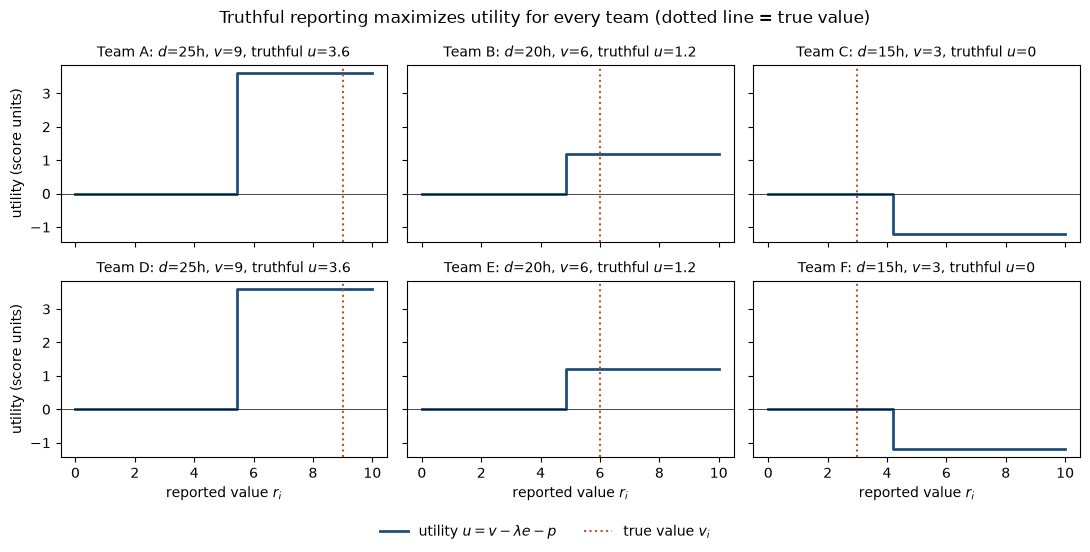

In [15]:
# Utility vs. report for every team (rivals fixed). Matplotlib ships with Colab.
import matplotlib.pyplot as plt

grid = [step / 20 for step in range(201)]   # reports 0, 0.05, ..., 10
fig, axes = plt.subplots(2, 3, figsize=(11, 5.5), sharex=True, sharey=True)
for index, (team, ax) in enumerate(zip(teams, axes.ravel())):
    rows = misreport_sweep(teams, index, grid)
    ax.step(grid, [r['utility_score_units'] for r in rows], where='post',
            color='#1f4e79', lw=2, label=r'utility $u = v - \lambda e - p$')
    ax.axvline(team.true_value, color='#b5562b', ls=':', lw=1.5, label='true value $v_i$')
    ax.axhline(0, color='black', lw=0.5)
    truthful_u = next(r for r in misreport_sweep(teams, index, [team.true_value]))['utility_score_units']
    ax.set_title(f'{team.name}: $d$={team.demand_gpu_hours:g}h, $v$={team.true_value:g}, '
                 f'truthful $u$={truthful_u:g}', fontsize=10)
for ax in axes[1]:
    ax.set_xlabel('reported value $r_i$')
for ax in axes[:, 0]:
    ax.set_ylabel('utility (score units)')
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='lower center', ncol=2, frameon=False)
fig.suptitle('Truthful reporting maximizes utility for every team (dotted line = true value)', fontsize=12)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## Random-order FCFS over every arrival order

Random-order FCFS depends on luck. Instead of sampling with a seed, the cell computes all $6! = 720$ orders exactly and compares their distribution with the single VCG outcome.

In [16]:
all_orders = fcfs_all_orders(teams, CAPACITY_GPU_HOURS)
order_summary = summarize_fcfs_orders(teams, all_orders)
print(f"{'metric':36} {'FCFS mean':>10} {'FCFS min–max':>14} {'VCG':>8}")
print('-' * 72)
for key in ['teams_served', 'gpu_hours_used', 'total_true_project_value',
            'carbon_adjusted_true_score', 'total_estimated_emissions_kg_co2e']:
    s = order_summary[key]
    print(f"{key:36} {s['mean']:>10} {str(s['min']) + '–' + str(s['max']):>14} {vcg_summary[key]:>8}")
print('\nChance of being served under FCFS:', order_summary['service_probability'])
print('VCG serves:', vcg_summary['selected_teams'])

metric                                FCFS mean   FCFS min–max      VCG
------------------------------------------------------------------------
teams_served                               4.93        4.0–5.0        4
gpu_hours_used                             97.0     90.0–100.0       90
total_true_project_value                   28.6      27.0–30.0       30
carbon_adjusted_true_score                16.96      15.6–19.2     19.2
total_estimated_emissions_kg_co2e         23.28      21.6–24.0     21.6

Chance of being served under FCFS: {'Team A': 0.767, 'Team B': 0.767, 'Team C': 0.933, 'Team D': 0.767, 'Team E': 0.767, 'Team F': 0.933}
VCG serves: Team A; Team B; Team D; Team E


## Carbon-penalty sensitivity check

The baseline uses $\lambda=0.5$. This check sweeps the announced carbon weight from 0 to 1 in steps of 0.1, holding demands, values, capacity, and the allocation algorithm fixed, and re-runs the DSIC check at every $\lambda$. It is a model robustness check, not behavioral evidence.

- $\lambda$ is a policy weight (how much the organization cares about carbon), not something to optimize: on project value alone, $\lambda=0$ always wins.
- At $\lambda=0$ the groups {A,B,C,D,F} and {A,B,D,E} tie on value (30); the public tie-break picks more teams. Any $\lambda>0$ breaks the tie toward fewer GPU-hours.


In [17]:
# Lambda sweep 0.0-1.0: allocation, emissions, payments, and DSIC at every carbon weight.
lambda_dsic = []
print(f"{'lambda':>6} {'selected':>9} {'GPU-h':>6} {'value':>6} {'CO2e':>6} {'score':>7} {'credits':>8} {'DSIC':>5}")
print('-' * 61)
for step in range(11):
    penalty = step / 10
    outcome = vcg_allocation(teams, CAPACITY_GPU_HOURS, carbon_penalty_per_kg_co2e=penalty)
    m = outcome_metrics(teams, outcome)
    dsic = all(
        max(r['utility_score_units'] for r in misreport_sweep(teams, i, reports, carbon_penalty_per_kg_co2e=penalty))
        <= round(team_utility(teams[i], outcome, i), 2) + 1e-9
        for i in range(len(teams)))
    assert dsic
    lambda_dsic.append(dsic)
    selected = ''.join(name[-1] for name in m['selected_teams'].split('; '))
    print(f"{penalty:>6.1f} {selected:>9} {m['gpu_hours_used']:>6g} {m['total_true_project_value']:>6g} "
          f"{m['total_estimated_emissions_kg_co2e']:>6g} {m['carbon_adjusted_true_score']:>7g} "
          f"{m['total_priority_payment_credits']:>8g} {'PASS':>5}")


lambda  selected  GPU-h  value   CO2e   score  credits  DSIC
-------------------------------------------------------------
   0.0     ABCDF    100     30     24      30      240  PASS
   0.1      ABDE     90     30   21.6   27.84    211.2  PASS
   0.2      ABDE     90     30   21.6   25.68    182.4  PASS
   0.3      ABDE     90     30   21.6   23.52    153.6  PASS


   0.4      ABDE     90     30   21.6   21.36    124.8  PASS
   0.5      ABDE     90     30   21.6    19.2       96  PASS


   0.6      ABDE     90     30   21.6   17.04     67.2  PASS
   0.7      ABDE     90     30   21.6   14.88     38.4  PASS
   0.8      ABDE     90     30   21.6   12.72      9.6  PASS


   0.9      ABDE     90     30   21.6   10.56        0  PASS
   1.0      ABDE     90     30   21.6     8.4        0  PASS


In [18]:
# What lambda changes: each team's selection boundary, price, and payoff (rivals truthful).
fine = [step / 20 for step in range(201)]   # reports 0, 0.05, ..., 10
print(f"{'lambda':>6} {'team':7} {'v':>3} {'seat if r >=':>13} {'payment':>8} {'utility':>8} {'max u at truth':>15}")
print('-' * 66)
for penalty in (0.1, 0.5, 1.0):
    outcome = vcg_allocation(teams, CAPACITY_GPU_HOURS, carbon_penalty_per_kg_co2e=penalty)
    for i, team in enumerate(teams):
        rows = misreport_sweep(teams, i, fine, carbon_penalty_per_kg_co2e=penalty)
        seat = next((r['report'] for r in rows if r['selected']), 'never')
        truthful = round(team_utility(team, outcome, i), 2)
        assert max(r['utility_score_units'] for r in rows) <= truthful + 1e-9
        print(f"{penalty:>6.1f} {team.name:7} {team.true_value:>3g} {str(seat):>13} "
              f"{outcome.payments_score_units.get(i, 0.0):>8} {truthful:>8} {'PASS':>15}")
    print()


lambda team      v  seat if r >=  payment  utility  max u at truth
------------------------------------------------------------------
   0.1 Team A    9           5.9     5.28     3.12            PASS


   0.1 Team B    6           5.8     5.28     0.24            PASS


   0.1 Team C    3          3.25      0.0      0.0            PASS


   0.1 Team D    9           5.9     5.28     3.12            PASS


   0.1 Team E    6           5.8     5.28     0.24            PASS
   0.1 Team F    3          3.25      0.0      0.0            PASS



...

   0.5 Team D    9          5.45      2.4      3.6            PASS
   0.5 Team E    6          4.85      2.4      1.2            PASS


   0.5 Team F    3           4.2      0.0      0.0            PASS

   1.0 Team A    9           6.0      0.0      3.0            PASS


   1.0 Team B    6           4.8      0.0      1.2            PASS
   1.0 Team C    3           4.8      0.0      0.0            PASS


   1.0 Team D    9           6.0      0.0      3.0            PASS
   1.0 Team E    6           4.8      0.0      1.2            PASS


   1.0 Team F    3          4.85      0.0      0.0            PASS



**What $\lambda$ changes.** The carbon weight moves three things, all visible above:

- **Who competes for a seat.** At $\lambda=0.1$ carbon is cheap, so the low-value teams C and F still want a seat; competition is stiff and each winner pays 5.28. As $\lambda$ rises, their scores turn negative, competition fades, and payments fall to 2.4 at $\lambda=0.5$ and to 0 from $\lambda=0.9$.
- **Each winner's payoff.** Teams A and D earn 3.12, 3.6, and 3.0 at $\lambda = 0.1, 0.5, 1.0$; teams B and E earn 0.24, 1.2, and 1.2. A lower price raises the payoff, while a heavier own carbon charge $\lambda e_i$ lowers it.
- **The selection boundary.** The report at which a team wins a seat shifts with $\lambda$ (Team C: 3.25, 4.2, 4.8).

**What $\lambda$ does not change.** For every team and every $\lambda$, utility peaks at the truthful report $r_i=v_i$. The price never depends on a team's own report, so $\lambda$ moves the boundary and the size of the payoff but never the best strategy. $\lambda$ is therefore a policy choice about efficiency and carbon, not about incentives.


### Truthful reporting stays optimal at every carbon weight

Same panels as above, now drawn for $\lambda = 0.1, 0.5, 1.0$. Changing $\lambda$ moves each team's **selection boundary** (the report at which the step appears) and its payment, but the highest point of every curve is still at the dotted line $r_i = v_i$.


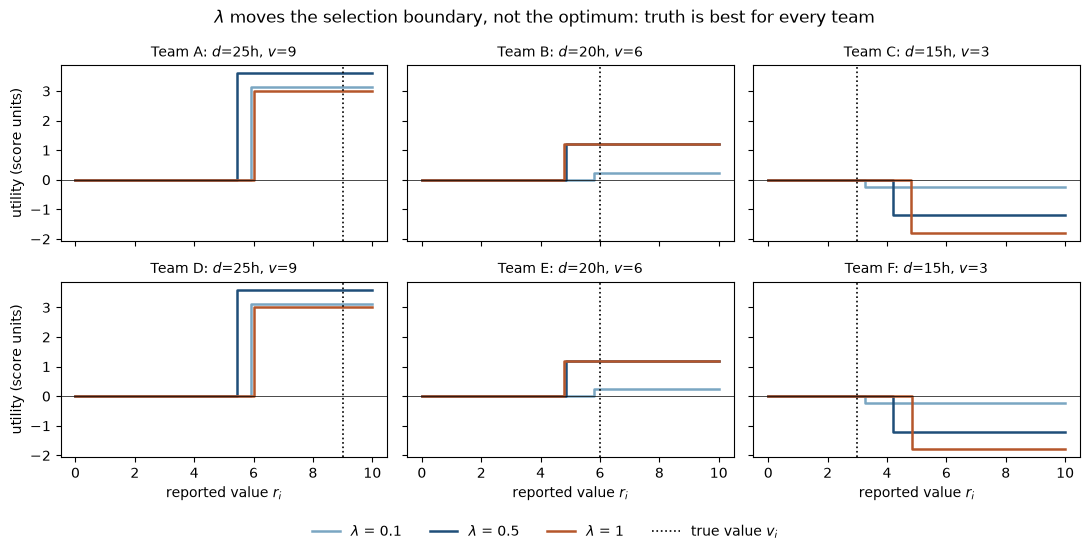

In [19]:
# Utility vs. report for every team at three carbon weights (rivals fixed and truthful).
penalties = (0.1, 0.5, 1.0)
colors = ('#7aa6c2', '#1f4e79', '#b5562b')
fig, axes = plt.subplots(2, 3, figsize=(11, 5.5), sharex=True, sharey=True)
for index, (team, ax) in enumerate(zip(teams, axes.ravel())):
    for penalty, color in zip(penalties, colors):
        rows = misreport_sweep(teams, index, grid, carbon_penalty_per_kg_co2e=penalty)
        ax.step(grid, [r['utility_score_units'] for r in rows], where='post', color=color, lw=1.8,
                label=fr'$\lambda$ = {penalty:g}')
    ax.axvline(team.true_value, color='black', ls=':', lw=1.2, label='true value $v_i$')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{team.name}: $d$={team.demand_gpu_hours:g}h, $v$={team.true_value:g}', fontsize=10)
for ax in axes[1]:
    ax.set_xlabel('reported value $r_i$')
for ax in axes[:, 0]:
    ax.set_ylabel('utility (score units)')
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='lower center', ncol=4, frameon=False)
fig.suptitle(r'$\lambda$ moves the selection boundary, not the optimum: truth is best for every team', fontsize=12)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()


## Extension: two GPU types (H100 and A100)

Reviewer question (Zimu Zhou, FP11): real clusters have more than one GPU type. This extension splits the same 100 GPU-hours into two pools and lets the mechanism also choose **which pool** each selected team uses.

| Pool | GPU-hours | kg CO₂e per GPU-hour |
|---|---:|---:|
| H100 | 50 | 0.24 (the baseline rate) |
| A100 | 50 | 0.14 |

Assumptions: a team runs entirely on one pool and needs the same GPU-hours on either type (no speed difference). The score becomes $s_i = r_i - \lambda \cdot \text{rate}_g \cdot d_i$ for the assigned pool $g$, and the mechanism searches all $3^6 = 729$ assignments (no GPU / H100 / A100). VCG payments and the DSIC check work exactly as before, because the Groves argument only needs the best feasible outcome to be found exactly.


In [20]:
# Two-pool carbon-aware VCG: choose who is served AND on which GPU type.
from itertools import product

POOLS = {'H100': (50.0, 0.24), 'A100': (50.0, 0.14)}   # (GPU-hours, kg CO2e per GPU-hour)

def pool_score(team, pool, reported=True, penalty=CARBON_PENALTY_PER_KG_CO2E):
    value = team.reported_value if reported else team.true_value
    return value - penalty * POOLS[pool][1] * team.demand_gpu_hours

def best_assignment(teams, excluded=None):
    # Exact search over every assignment; ties: more teams, then earlier teams served.
    best_key, best_plan = None, None
    for plan in product((None, *POOLS), repeat=len(teams)):
        if excluded is not None and plan[excluded] is not None:
            continue
        if any(sum(t.demand_gpu_hours for t, p in zip(teams, plan) if p == g) > POOLS[g][0] for g in POOLS):
            continue
        score = sum(pool_score(t, p) for t, p in zip(teams, plan) if p)
        key = (round(score, 9), sum(p is not None for p in plan), tuple(p is not None for p in plan))
        if best_key is None or key > best_key:
            best_key, best_plan = key, plan
    return best_plan, best_key[0]

def vcg_two_pools(teams):
    plan, _ = best_assignment(teams)
    payments = {}
    for i, pool in enumerate(plan):
        if pool:
            _, best_without_i = best_assignment(teams, excluded=i)
            others = sum(pool_score(t, q) for j, (t, q) in enumerate(zip(teams, plan)) if q and j != i)
            payments[i] = round(max(0.0, best_without_i - others), 2)
    return plan, payments

def pool_utility(teams, i, plan, payments):
    return round(pool_score(teams[i], plan[i], reported=False) - payments[i], 2) if plan[i] else 0.0

plan, payments = vcg_two_pools(teams)
print(f"{'team':8} {'pool':>5} {'CO2e':>6} {'payment':>8} {'utility':>8}")
print('-' * 40)
for i, team in enumerate(teams):
    co2 = POOLS[plan[i]][1] * team.demand_gpu_hours if plan[i] else 0.0
    print(f"{team.name:8} {plan[i] or '-':>5} {co2:>6.2f} {payments.get(i, 0.0):>8} {pool_utility(teams, i, plan, payments):>8}")

served = [i for i, p in enumerate(plan) if p]
co2 = sum(POOLS[plan[i]][1] * teams[i].demand_gpu_hours for i in served)
value = sum(teams[i].true_value for i in served)
print(f"\nTwo pools : {len(served)} teams, {sum(teams[i].demand_gpu_hours for i in served):g} GPU-h, value {value:g}, "
      f"CO2e {co2:.1f} kg ({co2 / value:.3f} per value), credits {sum(payments.values()) * PRIORITY_CREDITS_PER_SCORE_UNIT:g}")
print(f"One pool  : {vcg_summary['teams_served']} teams, {vcg_summary['gpu_hours_used']:g} GPU-h, "
      f"value {vcg_summary['total_true_project_value']:g}, CO2e {vcg_summary['total_estimated_emissions_kg_co2e']:g} kg "
      f"({vcg_summary['total_estimated_emissions_kg_co2e'] / vcg_summary['total_true_project_value']:.3f} per value), "
      f"credits {vcg_summary['total_priority_payment_credits']:g}")

# DSIC check for the two-pool rule: no report in 0, 0.5, ..., 10 beats the truth.
for i, team in enumerate(teams):
    truthful_u = pool_utility(teams, i, plan, payments)
    for report in reports:
        changed = list(teams)
        changed[i] = Team(team.name, team.demand_gpu_hours, team.true_value, report)
        p, pay = vcg_two_pools(changed)
        assert pool_utility(changed, i, p, pay) <= truthful_u + 1e-9, (team.name, report)
two_pool_dsic, two_pool_co2 = True, co2
print('\nPASS  Truthful reporting optimal for all six teams under two GPU pools')


team      pool   CO2e  payment  utility
----------------------------------------
Team A    A100   3.50     3.65      3.6
Team B    H100   4.80      2.4      1.2
Team C       -   0.00      0.0      0.0
Team D    A100   3.50     3.65      3.6
Team E    H100   4.80      2.4      1.2
Team F       -   0.00      0.0      0.0

Two pools : 4 teams, 90 GPU-h, value 30, CO2e 16.6 kg (0.553 per value), credits 121
One pool  : 4 teams, 90 GPU-h, value 30, CO2e 21.6 kg (0.720 per value), credits 96



PASS  Truthful reporting optimal for all six teams under two GPU pools


**Reading the two-pool result.**

- **Same winners, cleaner placement.** The mechanism still serves A, B, D, and E, but it places the two largest jobs (A and D, 25 GPU-hours each) on the cleaner A100 pool. Emissions fall from 21.6 to 16.6 kg CO₂e (−23%), or from 0.72 to 0.55 kg per unit of value.
- **Higher prices for A and D.** Their payments rise from 2.4 to 3.65: if A were absent, other teams could use its clean A100 hours, so A's externality on them is larger. B and E still pay 2.4.
- **Unchanged incentives.** Utilities are the same as with one pool (A and D 3.6, B and E 1.2), the selection boundaries are unchanged, and no report beats the truth. The Groves argument needs only that the best feasible outcome is found exactly; it does not care how many capacity constraints there are.
- **Limitation.** The cell assumes a job needs the same GPU-hours on either type. In practice an A100 is slower than an H100, so the same job would need more A100 hours; this extension is a structural check, not an emissions estimate.


In [21]:
# Fresh-run verification record.
import platform
from datetime import datetime, timezone

checks = {
    'FCFS illustrative order uses 95 GPU-hours': fcfs_summary['gpu_hours_used'] == 95.0,
    'VCG selects A, B, D, E using 90 GPU-hours': (vcg_summary['selected_teams'], vcg_summary['gpu_hours_used']) == ('Team A; Team B; Team D; Team E', 90.0),
    'VCG total true value 30, carbon-adjusted score 19.2': (vcg_summary['total_true_project_value'], vcg_summary['carbon_adjusted_true_score']) == (30.0, 19.2),
    'VCG payments total 96 credits': vcg_summary['total_priority_payment_credits'] == 96.0,
    'Utilities A-F = 3.6, 1.2, 0, 3.6, 1.2, 0': [r['utility_score_units'] for r in team_rows(teams, vcg)] == [3.6, 1.2, 0.0, 3.6, 1.2, 0.0],
    'Truthful reporting optimal for all six teams': all(
        max(r['utility_score_units'] for r in misreport_sweep(teams, i, reports))
        <= next(r for r in misreport_sweep(teams, i, reports) if r['truthful'])['utility_score_units'] + 1e-9
        for i in range(len(teams))),
    'FCFS covers 720 orders; none beats VCG score': order_summary['orders'] == 720
        and order_summary['carbon_adjusted_true_score']['max'] <= vcg_summary['carbon_adjusted_true_score'],
    'Truthful reporting optimal at every lambda in 0.0-1.0': len(lambda_dsic) == 11 and all(lambda_dsic),
    'Two GPU pools: truth optimal; emissions 21.6 -> 16.6 kg': two_pool_dsic and round(two_pool_co2, 1) == 16.6,
}
print('Run at (UTC):', datetime.now(timezone.utc).isoformat(timespec='seconds'))
print('Python:', platform.python_version(), '|', platform.platform())
for name, ok in checks.items():
    print(('PASS  ' if ok else 'FAIL  ') + name)
assert all(checks.values())

Run at (UTC): 2026-10-03T04:08:12+00:00
Python: 3.14.7 | macOS-26.6.2-arm64-arm-64bit-Mach-O
PASS  FCFS illustrative order uses 95 GPU-hours
PASS  VCG selects A, B, D, E using 90 GPU-hours
PASS  VCG total true value 30, carbon-adjusted score 19.2
PASS  VCG payments total 96 credits
PASS  Utilities A-F = 3.6, 1.2, 0, 3.6, 1.2, 0
PASS  Truthful reporting optimal for all six teams
PASS  FCFS covers 720 orders; none beats VCG score
PASS  Truthful reporting optimal at every lambda in 0.0-1.0
PASS  Two GPU pools: truth optimal; emissions 21.6 -> 16.6 kg


`run_simulation.py` writes the same results to `outputs/`: `summary.csv`, `fcfs_team_results.csv`, `vcg_team_results.csv`, `fcfs_all_orders.csv`, `truthfulness_check.csv`, and `lambda_sweep.csv`. The two-GPU-pool extension lives only in this notebook. Automated tests: `python -m unittest discover -s tests -v`.